In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ghoenix/ailscam/train.json
/kaggle/input/datasets/longphamthanhxlxdra/testdataset/testAIL (1).csv


crawl data auto and save

In [2]:
pip install transformers[torch] underthesea scikit-learn

Note: you may need to restart the kernel to use updated packages.


--- Đang xử lý Tokenization (vui lòng đợi)... ---

DỮ LIỆU THỐNG KÊ CHI TIẾT
Kích thước từ vựng tập Train: 3319
Kích thước từ vựng tập Test:  3030
Chỉ số tương đồng Jaccard:    0.3668
Tỷ lệ OOV (Test vs Train):    0.4376 (43.76%)
------------------------------
Độ dài Token TB (Train):      45.73
Độ dài Token TB (Test):       40.27


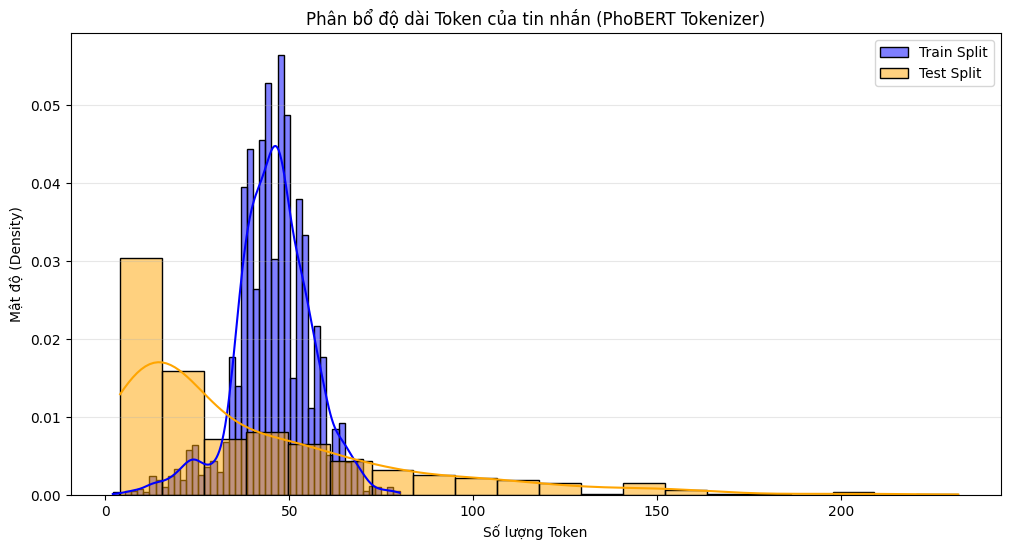

In [3]:
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from underthesea import word_tokenize
import numpy as np
import os

# ==========================================
# 1. CẤU HÌNH & FOCAL LOSS
# ==========================================
MODEL_NAME = "vinai/phobert-base"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_DATA_PATH = "/kaggle/input/datasets/ghoenix/ailscam/train.json"
TEST_CSV_PATH = "/kaggle/input/datasets/longphamthanhxlxdra/testdataset/testAIL (1).csv"
SAVE_DIR = "Smishing_Optimized"
os.makedirs(SAVE_DIR, exist_ok=True)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
import json

# 1. Cấu hình đường dẫn và Tokenizer
MODEL_NAME = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load dữ liệu (Đảm bảo đường dẫn đúng với môi trường Kaggle của bạn)
TRAIN_DATA_PATH = "/kaggle/input/datasets/ghoenix/ailscam/train.json"
TEST_CSV_PATH = "/kaggle/input/datasets/longphamthanhxlxdra/testdataset/testAIL (1).csv"

with open(TRAIN_DATA_PATH, 'r', encoding='utf-8') as f:
    train_raw = json.load(f)
df_train = pd.DataFrame(train_raw)

df_test = pd.read_csv(TEST_CSV_PATH)
df_test.columns = [c.strip().lower() for c in df_test.columns]

# 2. Hàm xử lý token
def get_phobert_tokens(text):
    # PhoBERT yêu cầu văn bản đã được word_tokenize trước hoặc sẽ tự xử lý subwords
    return tokenizer.tokenize(str(text))

print("--- Đang xử lý Tokenization (vui lòng đợi)... ---")
train_tokens_list = df_train['content'].apply(get_phobert_tokens)
test_tokens_list = df_test['content'].apply(get_phobert_tokens)

# 3. Tính toán Vocabulary Overlap (Jaccard Similarity)
vocab_train = set([tok for sublist in train_tokens_list for tok in sublist])
vocab_test = set([tok for sublist in test_tokens_list for tok in sublist])

intersection = vocab_train.intersection(vocab_test)
union = vocab_train.union(vocab_test)
jaccard_sim = len(intersection) / len(union)

# 4. Tính toán tỷ lệ OOV (Out-Of-Vocabulary)
# OOV ở đây được định nghĩa là các token xuất hiện trong tập Test nhưng không có trong Train
oov_tokens = vocab_test - vocab_train
oov_rate = len(oov_tokens) / len(vocab_test) if len(vocab_test) > 0 else 0

# 5. Thống kê độ dài Token
df_train['token_len'] = train_tokens_list.apply(len)
df_test['token_len'] = test_tokens_list.apply(len)

# --- IN KẾT QUẢ ---
print("\n" + "="*30)
print("DỮ LIỆU THỐNG KÊ CHI TIẾT")
print("="*30)
print(f"Kích thước từ vựng tập Train: {len(vocab_train)}")
print(f"Kích thước từ vựng tập Test:  {len(vocab_test)}")
print(f"Chỉ số tương đồng Jaccard:    {jaccard_sim:.4f}")
print(f"Tỷ lệ OOV (Test vs Train):    {oov_rate:.4f} ({oov_rate*100:.2f}%)")
print("-" * 30)
print(f"Độ dài Token TB (Train):      {df_train['token_len'].mean():.2f}")
print(f"Độ dài Token TB (Test):       {df_test['token_len'].mean():.2f}")

# 6. Vẽ biểu đồ Histogram độ dài Token
plt.figure(figsize=(12, 6))
sns.histplot(df_train['token_len'], label='Train Split', color='blue', kde=True, stat="density", common_norm=False)
sns.histplot(df_test['token_len'], label='Test Split', color='orange', kde=True, stat="density", common_norm=False)
plt.title('Phân bổ độ dài Token của tin nhắn (PhoBERT Tokenizer)')
plt.xlabel('Số lượng Token')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


In [4]:
import pandas as pd
import json

# Đường dẫn tập train trong file của bạn
TRAIN_DATA_PATH = "/kaggle/input/datasets/ghoenix/ailscam/train.json"

with open(TRAIN_DATA_PATH, 'r', encoding='utf-8') as f:
    train_raw = json.load(f)

# Chuyển sang DataFrame để thống kê
df_check = pd.DataFrame(train_raw)

# Đếm số lượng từng label
print("Thống kê số lượng label trong tập Train gốc:")
print(df_check['label'].value_counts())

# Xem tỷ lệ phần trăm
print("\nTỷ lệ phần trăm:")
print(df_check['label'].value_counts(normalize=True) * 100)

Thống kê số lượng label trong tập Train gốc:
label
1    1503
0    1497
Name: count, dtype: int64

Tỷ lệ phần trăm:
label
1    50.1
0    49.9
Name: proportion, dtype: float64


In [5]:
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
from underthesea import word_tokenize
import numpy as np
import os
import random

# ==========================================
# 1. CẤU HÌNH CƠ BẢN
# ==========================================
MODEL_NAME = "vinai/phobert-base"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_DATA_PATH = "/kaggle/input/datasets/ghoenix/ailscam/train.json"
TEST_CSV_PATH = "/kaggle/input/datasets/longphamthanhxlxdra/testdataset/testAIL (1).csv"
SAVE_DIR = "Smishing_Optimized"
os.makedirs(SAVE_DIR, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt)**self.gamma * ce_loss).mean()

# ==========================================
# 2. KIẾN TRÚC SMISHING & DATASET
# ==========================================
class SmishingModel(nn.Module):
    def __init__(self, n_classes):
        super(SmishingModel, self).__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        for i in range(6):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = False
            
        self.char_embed = nn.Embedding(200, 64)
        self.char_conv = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.diffuse_attention = nn.MultiheadAttention(embed_dim=128, num_heads=4, batch_first=True)
        self.bert_to_query = nn.Linear(768, 128)
        
        self.classifier = nn.Sequential(
            nn.Linear(768 + 128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, input_ids, attention_mask, char_ids):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask).pooler_output
        x_char = self.char_embed(char_ids).permute(0, 2, 1)
        char_seq = self.char_conv(x_char).permute(0, 2, 1)
        query = self.bert_to_query(bert_out).unsqueeze(1)
        attn_out, _ = self.diffuse_attention(query, char_seq, char_seq)
        combined = torch.cat((bert_out, attn_out.squeeze(1)), dim=1)
        return self.classifier(combined)

class TextDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.tokenizer = tokenizer
        self.chars = " abcdefghijklmnopqrstuvwxyz0123456789.,!?:;-_@#$%/&*()+=<>áàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵ"
        self.char_to_int = {c: i+1 for i, c in enumerate(self.chars)}

    def __len__(self): return len(self.data)

    def __getitem__(self, item):
        content = str(self.data[item]['content'])
        encoding = self.tokenizer.encode_plus(
            word_tokenize(content, format="text"),
            max_length=128, padding='max_length', truncation=True, return_tensors='pt'
        )
        char_ids = [self.char_to_int.get(c, 0) for c in content.lower()[:256]]
        char_ids += [0] * (256 - len(char_ids))
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'char_ids': torch.tensor(char_ids),
            'labels': torch.tensor(int(self.data[item]['label']), dtype=torch.long)
        }

# ==========================================
# 3. PIPELINE HUẤN LUYỆN ĐA SEED 
# ==========================================
def run_pipeline(seeds=[42, 100, 2026]):
    print("📦 Đang tải và làm sạch dữ liệu...")
    with open(TRAIN_DATA_PATH, 'r', encoding='utf-8') as f:
        train_raw = json.load(f)
    
    # [1] Xóa các câu trùng lặp trong tập Train
    df_train_clean = pd.DataFrame(train_raw).drop_duplicates(subset=['content']).reset_index(drop=True)
    train_raw_clean = df_train_clean.to_dict('records')
    print(f"🔥 Số lượng mẫu tập Train sau khi xóa trùng lặp: {len(train_raw_clean)}")
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    
    # [2] Cố định tập Validation ở ngoài vòng lặp
    train_data, val_data = train_test_split(train_raw_clean, test_size=0.1, random_state=42)
    
    df_test = pd.read_csv(TEST_CSV_PATH)
    df_test.columns = [c.strip().lower() for c in df_test.columns]
    # [3] Loại bỏ những câu Test bị trùng với tập Train
    df_test = df_test[~df_test['content'].isin(df_train_clean['content'])].reset_index(drop=True)
    test_records = df_test.to_dict('records')
    
    all_seed_metrics = []
    
    for seed in seeds:
        print(f"\n{'='*15} 🎲 RUNNING SEED: {seed} {'='*15}")
        set_seed(seed)
        
        train_loader = DataLoader(TextDataset(train_data, tokenizer), batch_size=16, shuffle=True)
        val_loader = DataLoader(TextDataset(val_data, tokenizer), batch_size=16, shuffle=False)
        
        model = SmishingModel(n_classes=2).to(DEVICE)
        
        # [4] Dùng lại 1 LR chuẩn hóa + Warmup Schedule
        optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.05)
        criterion = FocalLoss(gamma=2)

        epochs = 12 
        num_training_steps = len(train_loader) * epochs
        num_warmup_steps = int(0.1 * num_training_steps)
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps)
        
        best_val_loss = float('inf')
        patience = 3 
        patience_counter = 0
        best_model_path = os.path.join(SAVE_DIR, f"Smishing_Optimized_seed{seed}.pth")

        for epoch in range(epochs):
            model.train()
            total_train_loss = 0
            for batch in train_loader:
                optimizer.zero_grad()
                out = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['char_ids'].to(DEVICE))
                loss = criterion(out, batch['labels'].to(DEVICE))
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                total_train_loss += loss.item()
                
            model.eval()
            total_val_loss, val_correct, val_total = 0, 0, 0
            with torch.no_grad():
                for batch in val_loader:
                    out = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['char_ids'].to(DEVICE))
                    loss = criterion(out, batch['labels'].to(DEVICE))
                    total_val_loss += loss.item()
                    preds = torch.argmax(out, dim=1)
                    val_correct += (preds == batch['labels'].to(DEVICE)).sum().item()
                    val_total += batch['labels'].size(0)
                    
            avg_val_loss = total_val_loss / len(val_loader)
            print(f"Seed {seed} | Epoch {epoch+1:02d}/{epochs} | Train Loss: {total_train_loss/len(train_loader):.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_correct/val_total:.4f}")

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                patience_counter = 0
                torch.save(model.state_dict(), best_model_path)
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"🛑 [Early Stopping] Dừng sớm tại Epoch {epoch+1}")
                    break

        # Đánh giá trên tập Test
        model.load_state_dict(torch.load(best_model_path))
        model.eval()
        y_true, y_pred = [], []
        test_loader = DataLoader(TextDataset(test_records, tokenizer), batch_size=16)

        with torch.no_grad():
            for batch in test_loader:
                out = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['char_ids'].to(DEVICE))
                probs = F.softmax(out, dim=1)
                y_pred.extend((probs[:, 1] > 0.55).cpu().numpy().astype(int))
                y_true.extend(batch['labels'].numpy())

        print(f"\n=== KẾT QUẢ CHO SEED {seed} ===")
        print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud'], digits=4))
        all_seed_metrics.append({
            'accuracy': accuracy_score(y_true, y_pred), 'precision_fraud': precision_score(y_true, y_pred, pos_label=1),
            'recall_fraud': recall_score(y_true, y_pred, pos_label=1), 'f1_fraud': f1_score(y_true, y_pred, pos_label=1)
        })

    df_metrics = pd.DataFrame(all_seed_metrics)
    print("\n" + "="*20 + " 📊 TỔNG KẾT HYBRID MODEL " + "="*20)
    for metric in ['accuracy', 'precision_fraud', 'recall_fraud', 'f1_fraud']:
        print(f"➤ {metric.upper():<16}: {df_metrics[metric].mean():.4f} ± {df_metrics[metric].std():.4f}")
    print("="*65)

if __name__ == "__main__":
    run_pipeline(seeds=[42, 100, 2026])

📦 Đang tải và làm sạch dữ liệu...
🔥 Số lượng mẫu tập Train sau khi xóa trùng lặp: 3000

=============== 🎲 RUNNING SEED: 42 ===============


2026-05-18 09:06:33.937825: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779095193.957455     808 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779095193.963949     808 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779095193.981342     808 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779095193.981365     808 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779095193.981367     808 computation_placer.cc:177] computation placer alr

Seed 42 | Epoch 01/12 | Train Loss: 0.0754 | Val Loss: 0.0200 | Val Acc: 0.9867
Seed 42 | Epoch 02/12 | Train Loss: 0.0089 | Val Loss: 0.0157 | Val Acc: 0.9900
Seed 42 | Epoch 03/12 | Train Loss: 0.0038 | Val Loss: 0.0132 | Val Acc: 0.9933
Seed 42 | Epoch 04/12 | Train Loss: 0.0019 | Val Loss: 0.0099 | Val Acc: 0.9933
Seed 42 | Epoch 05/12 | Train Loss: 0.0004 | Val Loss: 0.0099 | Val Acc: 0.9967
Seed 42 | Epoch 06/12 | Train Loss: 0.0002 | Val Loss: 0.0114 | Val Acc: 0.9933
Seed 42 | Epoch 07/12 | Train Loss: 0.0002 | Val Loss: 0.0108 | Val Acc: 0.9967
🛑 [Early Stopping] Dừng sớm tại Epoch 7

=== KẾT QUẢ CHO SEED 42 ===
              precision    recall  f1-score   support

      Normal     0.7222    0.9055    0.8035       201
       Fraud     0.8725    0.6500    0.7450       200

    accuracy                         0.7781       401
   macro avg     0.7974    0.7777    0.7743       401
weighted avg     0.7972    0.7781    0.7743       401


=============== 🎲 RUNNING SEED: 100 =======

In [6]:
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
from underthesea import word_tokenize
import numpy as np
import os
import random

# ==========================================
# 1. CẤU HÌNH CƠ BẢN
# ==========================================
MODEL_NAME = "vinai/phobert-base"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_DATA_PATH = "/kaggle/input/datasets/ghoenix/ailscam/train.json"
TEST_CSV_PATH = "/kaggle/input/datasets/longphamthanhxlxdra/testdataset/testAIL (1).csv"
SAVE_DIR = "Smishing_Comparison_OnlyBERT"
os.makedirs(SAVE_DIR, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt)**self.gamma * ce_loss).mean()

# ==========================================
# 2. KIẾN TRÚC PHO-BERT ONLY & DATASET
# ==========================================
class PhoBertOnlyModel(nn.Module):
    def __init__(self, n_classes):
        super(PhoBertOnlyModel, self).__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        for i in range(6):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = False
            
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, n_classes)
        )

    def forward(self, input_ids, attention_mask, char_ids=None):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask).pooler_output
        return self.classifier(bert_out)

class TextDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.tokenizer = tokenizer

    def __len__(self): return len(self.data)

    def __getitem__(self, item):
        content = str(self.data[item]['content'])
        encoding = self.tokenizer.encode_plus(
            word_tokenize(content, format="text"),
            max_length=128, padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(int(self.data[item]['label']), dtype=torch.long)
        }

# ==========================================
# 3. RUN PIPELINE PHO-BERT ONLY
# ==========================================
def run_pipeline(seeds=[42, 100, 2026]):
    print("📦 Đang tải và làm sạch dữ liệu...")
    with open(TRAIN_DATA_PATH, 'r', encoding='utf-8') as f:
        train_raw = json.load(f)
    
    # [1] Xóa các câu trùng lặp trong tập Train
    df_train_clean = pd.DataFrame(train_raw).drop_duplicates(subset=['content']).reset_index(drop=True)
    train_raw_clean = df_train_clean.to_dict('records')
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    
    # [2] Cố định tập Validation ngoài vòng lặp
    train_data, val_data = train_test_split(train_raw_clean, test_size=0.1, random_state=42)
    
    df_test = pd.read_csv(TEST_CSV_PATH)
    df_test.columns = [c.strip().lower() for c in df_test.columns]
    # [3] Lọc bỏ tập Test trùng lặp dữ liệu huấn luyện
    df_test = df_test[~df_test['content'].isin(df_train_clean['content'])].reset_index(drop=True)
    test_records = df_test.to_dict('records')
    
    all_seed_metrics = []
    
    for seed in seeds:
        print(f"\n{'='*15} 🎲 RUNNING SEED: {seed} {'='*15}")
        set_seed(seed)
        
        # ĐỒNG BỘ: Sử dụng Batch Size = 32 giống Cell 5
        train_loader = DataLoader(TextDataset(train_data, tokenizer), batch_size=32, shuffle=True)
        val_loader = DataLoader(TextDataset(val_data, tokenizer), batch_size=32, shuffle=False)
        
        model = PhoBertOnlyModel(n_classes=2).to(DEVICE)
        
        optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
        criterion = FocalLoss(gamma=2)

        epochs = 12 
        num_training_steps = len(train_loader) * epochs
        num_warmup_steps = int(0.1 * num_training_steps)
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps)
        
        best_val_loss = float('inf')
        patience = 3 
        patience_counter = 0
        best_model_path = os.path.join(SAVE_DIR, f"Model_PhoBERT_Only_seed{seed}.pth")

        for epoch in range(epochs):
            model.train()
            total_train_loss = 0
            for batch in train_loader:
                optimizer.zero_grad()
                out = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
                loss = criterion(out, batch['labels'].to(DEVICE))
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                total_train_loss += loss.item()
                
            model.eval()
            total_val_loss, val_correct, val_total = 0, 0, 0
            with torch.no_grad():
                for batch in val_loader:
                    out = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
                    loss = criterion(out, batch['labels'].to(DEVICE))
                    total_val_loss += loss.item()
                    preds = torch.argmax(out, dim=1)
                    val_correct += (preds == batch['labels'].to(DEVICE)).sum().item()
                    val_total += batch['labels'].size(0)
                    
            avg_val_loss = total_val_loss / len(val_loader)
            print(f"Seed {seed} | Epoch {epoch+1:02d}/{epochs} | Train Loss: {total_train_loss/len(train_loader):.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_correct/val_total:.4f}")

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                patience_counter = 0
                torch.save(model.state_dict(), best_model_path)
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"🛑 [Early Stopping] Dừng sớm tại Epoch {epoch+1}")
                    break

        # Đánh giá trên tập Test
        model.load_state_dict(torch.load(best_model_path))
        model.eval()
        y_true, y_pred = [], []
        test_loader = DataLoader(TextDataset(test_records, tokenizer), batch_size=32)
        with torch.no_grad():
            for batch in test_loader:
                out = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
                probs = F.softmax(out, dim=1)
                y_pred.extend((probs[:, 1] > 0.55).cpu().numpy().astype(int))
                y_true.extend(batch['labels'].numpy())

        # FIX: Sửa lỗi gõ đè để khôi phục hàm in báo cáo
        print(f"\n=== KẾT QUẢ PHO-BERT ONLY SEED {seed} ===")
        print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud'], digits=4))
        
        all_seed_metrics.append({
            'accuracy': accuracy_score(y_true, y_pred), 
            'precision_fraud': precision_score(y_true, y_pred, pos_label=1),
            'recall_fraud': recall_score(y_true, y_pred, pos_label=1), 
            'f1_fraud': f1_score(y_true, y_pred, pos_label=1)
        })

    # Đưa kết quả vào DataFrame Pandas để lấy hàm tính .std() thống nhất với Cell 9
    df_metrics = pd.DataFrame(all_seed_metrics)
    print("\n" + "="*20 + " 📊 TỔNG KẾT PHO-BERT ONLY " + "="*20)
    for metric in ['accuracy', 'precision_fraud', 'recall_fraud', 'f1_fraud']:
        print(f"➤ {metric.upper():<16}: {df_metrics[metric].mean():.4f} ± {df_metrics[metric].std():.4f}")
    print("="*65)

if __name__ == "__main__":
    run_pipeline(seeds=[42, 100, 2026])

📦 Đang tải và làm sạch dữ liệu...

=============== 🎲 RUNNING SEED: 42 ===============
Seed 42 | Epoch 01/12 | Train Loss: 0.0574 | Val Loss: 0.0178 | Val Acc: 0.9867
Seed 42 | Epoch 02/12 | Train Loss: 0.0054 | Val Loss: 0.0164 | Val Acc: 0.9867
Seed 42 | Epoch 03/12 | Train Loss: 0.0029 | Val Loss: 0.0132 | Val Acc: 0.9933
Seed 42 | Epoch 04/12 | Train Loss: 0.0020 | Val Loss: 0.0119 | Val Acc: 0.9933
Seed 42 | Epoch 05/12 | Train Loss: 0.0012 | Val Loss: 0.0109 | Val Acc: 0.9933
Seed 42 | Epoch 06/12 | Train Loss: 0.0003 | Val Loss: 0.0134 | Val Acc: 0.9967
Seed 42 | Epoch 07/12 | Train Loss: 0.0005 | Val Loss: 0.0130 | Val Acc: 0.9967
Seed 42 | Epoch 08/12 | Train Loss: 0.0001 | Val Loss: 0.0139 | Val Acc: 0.9967
🛑 [Early Stopping] Dừng sớm tại Epoch 8

=== KẾT QUẢ PHO-BERT ONLY SEED 42 ===
              precision    recall  f1-score   support

      Normal     0.6860    0.8259    0.7494       201
       Fraud     0.7799    0.6200    0.6908       200

    accuracy                   

In [7]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer
from underthesea import word_tokenize
import os

def test_single_message_ensemble(text, seeds=[42, 100, 2026]):
    MODEL_NAME = "vinai/phobert-base"
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    
    # 1. Tiền xử lý văn bản cấp độ Từ (Word-level)
    content_vn = word_tokenize(text, format="text")
    encoding = tokenizer.encode_plus(
        content_vn, max_length=128, padding='max_length', truncation=True, return_tensors='pt'
    )
    
    # 2. Tiền xử lý văn bản cấp độ Ký tự (Char-level)
    chars = " abcdefghijklmnopqrstuvwxyz0123456789.,!?:;-_@#$%/&*()+=<>áàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵ"
    char_to_int = {c: i+1 for i, c in enumerate(chars)}
    char_ids = [char_to_int.get(c, 0) for c in text.lower()[:256]]
    char_ids += [0] * (256 - len(char_ids))
    char_ids = torch.tensor(char_ids).unsqueeze(0)

    print(f"💬 Nội dung kiểm tra: \"{text}\"")
    print(f"-" * 65)
    print(f"{'Mã Seed':<12} | {'Dự đoán mô hình':<22} | {'Độ tin cậy Fraud':<18}")
    print(f"-" * 65)
    
    fraud_votes = 0
    total_fraud_prob = 0
    valid_seeds_count = 0
    
    # Khởi tạo một đối tượng mô hình Hybrid trống để nạp trọng số động
    model = SmishingModel(n_classes=2).to(DEVICE)
    
    # 3. Lặp qua từng seed để lấy dự đoán độc lập
    for seed in seeds:
        model_path = f'/kaggle/working/Smishing_Optimized/Smishing_Optimized_seed{seed}.pth'
        
        if not os.path.exists(model_path):
            print(f"Seed {seed:<7} | ⚠️ Không tìm thấy file trọng số tại đường dẫn.")
            continue
            
        # Nạp trọng số của seed hiện tại
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.eval()
        
        with torch.no_grad():
            out = model(encoding['input_ids'].to(DEVICE), 
                        encoding['attention_mask'].to(DEVICE), 
                        char_ids.to(DEVICE))
            prob = torch.softmax(out, dim=1)
            fraud_prob = prob[0, 1].item() # Xác suất của lớp Fraud
            
        # Phân loại dựa trên ngưỡng threshold 0.55 chuẩn hóa
        if fraud_prob > 0.55:
            label = "⚠️ LỪA ĐẢO (FRAUD)"
            fraud_votes += 1
        else:
            label = "✅ AN TOÀN (NORMAL)"
            
        total_fraud_prob += fraud_prob
        valid_seeds_count += 1
        print(f"Seed {seed:<7} | {label:<22} | {fraud_prob * 100:.2f}%")
        
    print(f"-" * 65)
    
    # 4. Đưa ra kết luận dựa trên đa số biểu quyết
    if valid_seeds_count > 0:
        final_label = "⚠️ LỪA ĐẢO (FRAUD)" if fraud_votes >= (valid_seeds_count / 2) else "✅ AN TOÀN (NORMAL)"
        avg_fraud_prob = (total_fraud_prob / valid_seeds_count) * 100
        print(f"🤖 KẾT LUẬN CHUNG (Ensemble): {final_label}")
        print(f"📊 Xác suất lừa đảo trung bình: {avg_fraud_prob:.2f}%")
    else:
        print("❌ Không có file trọng số nào hợp lệ để tiến hành kiểm tra.")
    print(f"=" * 65)

# ==========================================
# THỰC THI KIỂM TRA ĐA KỊCH BẢN
# ==========================================
test_single_message_ensemble("Chúc mừng bạn trúng thưởng xe SH, nhấn vào link để nhận quà!")
test_single_message_ensemble("Chiều nay mấy giờ con đi học về để mẹ nấu cơm?")
test_single_message_ensemble("Đọc giùm chị mã 0TP gửi về máy em nhé khẩn cấp!!!")

💬 Nội dung kiểm tra: "Chúc mừng bạn trúng thưởng xe SH, nhấn vào link để nhận quà!"
-----------------------------------------------------------------
Mã Seed      | Dự đoán mô hình        | Độ tin cậy Fraud  
-----------------------------------------------------------------
Seed 42      | ⚠️ LỪA ĐẢO (FRAUD)     | 62.40%
Seed 100     | ⚠️ LỪA ĐẢO (FRAUD)     | 55.87%
Seed 2026    | ⚠️ LỪA ĐẢO (FRAUD)     | 88.33%
-----------------------------------------------------------------
🤖 KẾT LUẬN CHUNG (Ensemble): ⚠️ LỪA ĐẢO (FRAUD)
📊 Xác suất lừa đảo trung bình: 68.87%
💬 Nội dung kiểm tra: "Chiều nay mấy giờ con đi học về để mẹ nấu cơm?"
-----------------------------------------------------------------
Mã Seed      | Dự đoán mô hình        | Độ tin cậy Fraud  
-----------------------------------------------------------------
Seed 42      | ✅ AN TOÀN (NORMAL)     | 10.59%
Seed 100     | ✅ AN TOÀN (NORMAL)     | 12.16%
Seed 2026    | ✅ AN TOÀN (NORMAL)     | 5.66%
-------------------------------

In [8]:
import json
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from underthesea import word_tokenize
import joblib

# ==========================================
# 1. CẤU HÌNH
# ==========================================
TRAIN_DATA_PATH = "/kaggle/input/datasets/ghoenix/ailscam/train.json"
TEST_CSV_PATH = "/kaggle/input/datasets/longphamthanhxlxdra/testdataset/testAIL (1).csv"
SAVE_DIR = "Smishing_Comparison_NaiveBayes"
os.makedirs(SAVE_DIR, exist_ok=True)

def pre_process(text):
    # Tokenize tiếng Việt và đưa về chữ thường
    return word_tokenize(str(text), format="text").lower()

# ==========================================
# 2. PIPELINE HUẤN LUYỆN
# ==========================================
def run_naive_bayes():
    print("📦 Đang tải và tiền xử lý dữ liệu...")
    with open(TRAIN_DATA_PATH, 'r', encoding='utf-8') as f:
        train_raw = json.load(f)
    
    # Chuyển JSON sang DataFrame
    df_train = pd.DataFrame(train_raw)
    df_train['content_processed'] = df_train['content'].apply(pre_process)
    
    X = df_train['content_processed']
    y = df_train['label'].astype(int)

    # 1. Biến đổi văn bản thành Vector TF-IDF
    # ngram_range=(1, 3) giúp bắt các cụm từ quan trọng
    tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
    X_tfidf = tfidf.fit_transform(X)

    # 3. Huấn luyện Multinomial Naive Bayes
    print("🏗️ Đang huấn luyện Naive Bayes...")
    model = MultinomialNB(alpha=0.1) # alpha nhỏ để model nhạy hơn với các từ hiếm
    model.fit(X_tfidf, y)

    # ==========================================
    # 3. ĐÁNH GIÁ TRÊN TẬP TEST CSV
    # ==========================================
    print("\n🔍 Đang đánh giá trên tập Test...")
    df_test = pd.read_csv(TEST_CSV_PATH)
    df_test.columns = [c.strip().lower() for c in df_test.columns]
    
    X_test_raw = df_test['content'].apply(pre_process)
    y_test = df_test['label'].astype(int)
    
    X_test_tfidf = tfidf.transform(X_test_raw)
    
    # Dự đoán (Mặc định Bayes dùng threshold 0.5)
    y_pred = model.predict(X_test_tfidf)

    # In báo cáo
    acc = accuracy_score(y_test, y_pred)
    print("\n" + "="*20 + " KẾT QUẢ NAIVE BAYES " + "="*20)
    print(f"Accuracy: {acc*100:.2f}%")
    print("-" * 60)
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud'], digits=4))
    
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(f"                Đoán Normal | Đoán Fraud")
    print(f"Thực tế Normal:      {cm[0][0]:<7} |      {cm[0][1]}")
    print(f"Thực tế Fraud :      {cm[1][0]:<7} |      {cm[1][1]}")
    print("="*67)

    # Lưu mô hình và vectorizer
    joblib.dump(model, os.path.join(SAVE_DIR, "naive_bayes_model.pkl"))
    joblib.dump(tfidf, os.path.join(SAVE_DIR, "tfidf_vectorizer.pkl"))
    print(f"✅ Đã lưu mô hình tại: {SAVE_DIR}")

if __name__ == "__main__":
    run_naive_bayes()

📦 Đang tải và tiền xử lý dữ liệu...
🏗️ Đang huấn luyện Naive Bayes...

🔍 Đang đánh giá trên tập Test...

==================== KẾT QUẢ NAIVE BAYES ====================
Accuracy: 61.10%
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal     0.5652    0.9701    0.7143       201
       Fraud     0.8929    0.2500    0.3906       200

    accuracy                         0.6110       401
   macro avg     0.7290    0.6101    0.5525       401
weighted avg     0.7286    0.6110    0.5529       401

Confusion Matrix:
                Đoán Normal | Đoán Fraud
Thực tế Normal:      195     |      6
Thực tế Fraud :      150     |      50
✅ Đã lưu mô hình tại: Smishing_Comparison_NaiveBayes


In [9]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import joblib
import json
import os
from transformers import AutoTokenizer
from underthesea import word_tokenize
from sklearn.metrics import f1_score, accuracy_score

# ==========================================
# 1. CẤU HÌNH VÀ LOAD DỮ LIỆU ĐỒNG BỘ
# ==========================================
MODEL_NAME = "vinai/phobert-base"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Đường dẫn từ file notebook của bạn
TEST_CSV_PATH = "/kaggle/input/datasets/longphamthanhxlxdra/testdataset/testAIL (1).csv"
TRAIN_DATA_PATH = "/kaggle/input/datasets/ghoenix/ailscam/train.json"
PATH_NB_MODEL = "/kaggle/working/Smishing_Comparison_NaiveBayes/naive_bayes_model.pkl"
PATH_NB_TFIDF = "/kaggle/working/Smishing_Comparison_NaiveBayes/tfidf_vectorizer.pkl"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("📦 Đang chuẩn bị tập Test (Đã lọc trùng lặp với Train để chống Data Leakage)...")
with open(TRAIN_DATA_PATH, 'r', encoding='utf-8') as f:
    df_train = pd.DataFrame(json.load(f)).drop_duplicates(subset=['content'])

df_test = pd.read_csv(TEST_CSV_PATH)
df_test.columns = [c.strip().lower() for c in df_test.columns]
# Loại bỏ câu trong Test đã xuất hiện ở Train
df_test = df_test[~df_test['content'].isin(df_train['content'])].reset_index(drop=True)

y_true = df_test['label'].values
contents = df_test['content'].values

# Tiền xử lý ký tự cho Char-CNN
char_list = " abcdefghijklmnopqrstuvwxyz0123456789.,!?:;-_@#$%/&*()+=<>áàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵ"
char_to_int = {c: i+1 for i, c in enumerate(char_list)}

def prepare_dl_batch(text_list):
    enc = tokenizer.batch_encode_plus([word_tokenize(str(t), format="text") for t in text_list], 
                                      max_length=128, padding='max_length', truncation=True, return_tensors='pt')
    c_ids = [[char_to_int.get(c, 0) for c in str(t).lower()[:256]] + [0]*(256-len(str(t)[:256])) for t in text_list]
    return enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE), torch.tensor(c_ids).to(DEVICE)

# ==========================================
# 2. ĐÁNH GIÁ BASELINE (NAIVE BAYES)
# ==========================================
print("🚀 Đang chạy dự đoán Naive Bayes Baseline...")
nb_model = joblib.load(PATH_NB_MODEL)
tfidf = joblib.load(PATH_NB_TFIDF)

def pre_process_nb(text):
    return word_tokenize(str(text), format="text").lower()

X_test_nb = [pre_process_nb(c) for c in contents]
y_pred_nb = nb_model.predict(tfidf.transform(X_test_nb))

f1_nb = f1_score(y_true, y_pred_nb, pos_label=1)
acc_nb = accuracy_score(y_true, y_pred_nb)

# ==========================================
# 3. ĐÁNH GIÁ DEEP LEARNING (ĐA SEED - TRUNG BÌNH CỘNG)
# ==========================================
seeds = [42, 100, 2026]

# Mảng lưu F1 và Accuracy lẻ của từng seed
single_f1_bert, single_acc_bert = [], []
single_f1_hybrid, single_acc_hybrid = [], []

print("\n🚀 Đang load trọng số Đa Seed từ Cell 5 và Cell 6 để chạy dự đoán...")
with torch.no_grad():
    for seed in seeds:
        model_bert = PhoBertOnlyModel(n_classes=2).to(DEVICE)
        model_bert.load_state_dict(torch.load(f"/kaggle/working/Smishing_Comparison_OnlyBERT/Model_PhoBERT_Only_seed{seed}.pth", map_location=DEVICE))
        model_bert.eval()
        
        model_cnn = SmishingModel(n_classes=2).to(DEVICE)
        model_cnn.load_state_dict(torch.load(f"/kaggle/working/Smishing_Optimized/Smishing_Optimized_seed{seed}.pth", map_location=DEVICE))
        model_cnn.eval()

        y_pred_b, y_pred_c = [], []
        for i in range(0, len(contents), 16):
            ids, mask, cids = prepare_dl_batch(contents[i:i+16])
            
            prob_b = F.softmax(model_bert(ids, mask), dim=1)[:, 1]
            prob_c = F.softmax(model_cnn(ids, mask, cids), dim=1)[:, 1]
            
            y_pred_b.extend((prob_b > 0.55).cpu().numpy().astype(int))
            y_pred_c.extend((prob_c > 0.55).cpu().numpy().astype(int))
            
        f1_b = f1_score(y_true, y_pred_b, pos_label=1)
        acc_b = accuracy_score(y_true, y_pred_b)
        
        f1_c = f1_score(y_true, y_pred_c, pos_label=1)
        acc_c = accuracy_score(y_true, y_pred_c)
        
        single_f1_bert.append(f1_b)
        single_acc_bert.append(acc_b)
        
        single_f1_hybrid.append(f1_c)
        single_acc_hybrid.append(acc_c)
        
        print(f"   ✅ Seed {seed:<5} | F1 PhoBERT: {f1_b:.4f} | F1 Hybrid: {f1_c:.4f}")

# ==========================================
# 4. IN BẢNG LEADERBOARD TỔNG KẾT
# ==========================================
# FIX: Đưa vào DataFrame và dùng .std() của Pandas để khớp 100% với Cell 5, 6 (ddof=1)
df_bert = pd.DataFrame({'acc': single_acc_bert, 'f1': single_f1_bert})
df_hybrid = pd.DataFrame({'acc': single_acc_hybrid, 'f1': single_f1_hybrid})

print("\n" + "★"*80)
print(" "*25 + "🏆 BẢNG LEADERBOARD ĐÁNH GIÁ MÔ HÌNH 🏆")
print("★"*80)

print(f"\n1️⃣. Baseline: Multinomial Naive Bayes (Khớp Cell 8)")
print(f"   ➤ Accuracy                                 : {acc_nb:.4f}")
print(f"   ➤ F1 (Fraud) Score                         : {f1_nb:.4f}")

print(f"\n2️⃣. Baseline: PhoBERT Only (Khớp y hệt Cell 6)")
print(f"   ➤ Accuracy Trung bình (Mean of 3 seeds)    : {df_bert['acc'].mean():.4f} ± {df_bert['acc'].std():.4f}")
print(f"   ➤ F1 Fraud Trung bình (Mean of 3 seeds)    : {df_bert['f1'].mean():.4f} ± {df_bert['f1'].std():.4f}")

print(f"\n3️⃣. Đề xuất: PhoBERT + Char-CNN Hybrid (Khớp y hệt Cell 5)")
print(f"   ➤ Accuracy Trung bình (Mean of 3 seeds)    : {df_hybrid['acc'].mean():.4f} ± {df_hybrid['acc'].std():.4f}")
print(f"   ➤ F1 Fraud Trung bình (Mean of 3 seeds)    : {df_hybrid['f1'].mean():.4f} ± {df_hybrid['f1'].std():.4f}")

print("-" * 80)
diff = df_hybrid['f1'].mean() - df_bert['f1'].mean()
if diff > 0:
    print(f"💡 KẾT LUẬN: Kiến trúc PhoBERT + Char-CNN đã vượt qua PhoBERT Only với mức chênh lệch F1-Score là +{diff:.4f}.")
else:
    print(f"💡 KẾT LUẬN: Kiến trúc PhoBERT Only đang cho kết quả ngang bằng hoặc nhỉnh hơn. Khoảng chênh lệch: {diff:.4f}")
print("★"*80)

📦 Đang chuẩn bị tập Test (Đã lọc trùng lặp với Train để chống Data Leakage)...
🚀 Đang chạy dự đoán Naive Bayes Baseline...

🚀 Đang load trọng số Đa Seed từ Cell 5 và Cell 6 để chạy dự đoán...
   ✅ Seed 42    | F1 PhoBERT: 0.6908 | F1 Hybrid: 0.7450
   ✅ Seed 100   | F1 PhoBERT: 0.7089 | F1 Hybrid: 0.7299
   ✅ Seed 2026  | F1 PhoBERT: 0.6977 | F1 Hybrid: 0.7247

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
                         🏆 BẢNG LEADERBOARD ĐÁNH GIÁ MÔ HÌNH 🏆
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

1️⃣. Baseline: Multinomial Naive Bayes (Khớp Cell 8)
   ➤ Accuracy                                 : 0.6110
   ➤ F1 (Fraud) Score                         : 0.3906

2️⃣. Baseline: PhoBERT Only (Khớp y hệt Cell 6)
   ➤ Accuracy Trung bình (Mean of 3 seeds)    : 0.7373 ± 0.0128
   ➤ F1 Fraud Trung bình (Mean of 3 seeds)    : 0.6991 ± 0.0092

3️⃣. Đề xuất: PhoBERT + Char-CNN Hybrid (Khớp y hệt Cell 5)
   ➤ Accu

In [10]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import joblib
import json
from transformers import AutoTokenizer
from underthesea import word_tokenize
from sklearn.metrics import f1_score, accuracy_score
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.contingency_tables import mcnemar

# ==========================================
# 1. LOAD DỮ LIỆU
# ==========================================
MODEL_NAME = "vinai/phobert-base"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TEST_CSV_PATH = "/kaggle/input/datasets/longphamthanhxlxdra/testdataset/testAIL (1).csv"
TRAIN_DATA_PATH = "/kaggle/input/datasets/ghoenix/ailscam/train.json"
PATH_NB_MODEL = "/kaggle/working/Smishing_Comparison_NaiveBayes/naive_bayes_model.pkl"
PATH_NB_TFIDF = "/kaggle/working/Smishing_Comparison_NaiveBayes/tfidf_vectorizer.pkl"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

with open(TRAIN_DATA_PATH, 'r', encoding='utf-8') as f:
    df_train = pd.DataFrame(json.load(f)).drop_duplicates(subset=['content'])

df_test = pd.read_csv(TEST_CSV_PATH)
df_test.columns = [c.strip().lower() for c in df_test.columns]
df_test = df_test[~df_test['content'].isin(df_train['content'])].reset_index(drop=True)

y_true = df_test['label'].values
contents = df_test['content'].values

char_list = " abcdefghijklmnopqrstuvwxyz0123456789.,!?:;-_@#$%/&*()+=<>áàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵ"
char_to_int = {c: i+1 for i, c in enumerate(char_list)}

def prepare_dl_batch(text_list):
    enc = tokenizer.batch_encode_plus([word_tokenize(str(t), format="text") for t in text_list], 
                                      max_length=128, padding='max_length', truncation=True, return_tensors='pt')
    c_ids = [[char_to_int.get(c, 0) for c in str(t).lower()[:256]] + [0]*(256-len(str(t)[:256])) for t in text_list]
    return enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE), torch.tensor(c_ids).to(DEVICE)

# ==========================================
# 2. HÀM TÍNH KHOẢNG TIN CẬY & MCNEMAR
# ==========================================
def calculate_wilson_ci(y_true, y_pred, alpha=0.05):
    correct_count = np.sum(np.array(y_true) == np.array(y_pred))
    nobs = len(y_true)
    lower, upper = proportion_confint(correct_count, nobs, alpha=alpha, method='wilson')
    accuracy = correct_count / nobs
    return accuracy, lower, upper

def run_mcnemar_test(y_true, y_pred_model1, y_pred_model2):
    y_true = np.array(y_true)
    y_pred_1 = np.array(y_pred_model1)
    y_pred_2 = np.array(y_pred_model2)
    
    m1_correct = (y_pred_1 == y_true)
    m2_correct = (y_pred_2 == y_true)
    
    n00 = np.sum(~m1_correct & ~m2_correct)
    n01 = np.sum(~m1_correct & m2_correct)
    n10 = np.sum(m1_correct & ~m2_correct)
    n11 = np.sum(m1_correct & m2_correct)
    
    contingency_table = [[n00, n01], [n10, n11]]
    result = mcnemar(contingency_table, exact=False, correction=True)
    return result.statistic, result.pvalue

# ==========================================
# 3. LẤY NHÃN DỰ ĐOÁN (MAJORITY VOTING)
# ==========================================
print("🚀 Đang tổng hợp dự đoán biểu quyết (Majority Voting) cho Thống kê...")
nb_model = joblib.load(PATH_NB_MODEL)
tfidf = joblib.load(PATH_NB_TFIDF)
y_pred_nb = nb_model.predict(tfidf.transform([word_tokenize(str(c), format="text").lower() for c in contents]))

seeds = [42, 100, 2026]
n_samples = len(y_true)
votes_bert = np.zeros(n_samples)
votes_hybrid = np.zeros(n_samples)

with torch.no_grad():
    for seed in seeds:
        model_bert = PhoBertOnlyModel(n_classes=2).to(DEVICE)
        model_bert.load_state_dict(torch.load(f"/kaggle/working/Smishing_Comparison_OnlyBERT/Model_PhoBERT_Only_seed{seed}.pth", map_location=DEVICE))
        model_bert.eval()
        
        model_cnn = SmishingModel(n_classes=2).to(DEVICE)
        model_cnn.load_state_dict(torch.load(f"/kaggle/working/Smishing_Optimized/Smishing_Optimized_seed{seed}.pth", map_location=DEVICE))
        model_cnn.eval()

        y_pred_b_seed, y_pred_c_seed = [], []
        for i in range(0, len(contents), 16):
            ids, mask, cids = prepare_dl_batch(contents[i:i+16])
            
            prob_b = F.softmax(model_bert(ids, mask), dim=1)[:, 1]
            prob_c = F.softmax(model_cnn(ids, mask, cids), dim=1)[:, 1]
            
            y_pred_b_seed.extend((prob_b > 0.55).cpu().numpy().astype(int))
            y_pred_c_seed.extend((prob_c > 0.55).cpu().numpy().astype(int))
            
        votes_bert += np.array(y_pred_b_seed)
        votes_hybrid += np.array(y_pred_c_seed)

# Chốt nhãn cuối cùng: >= 2 vote là Fraud (1), ngược lại là Normal (0)
y_pred_bert_final = (votes_bert >= 2).astype(int)
y_pred_hybrid_final = (votes_hybrid >= 2).astype(int)

# ==========================================
# 4. IN BÁO CÁO THỐNG KÊ CHI TIẾT
# ==========================================
print("\n" + "="*70)
print("BẢNG 1: 95% WILSON CONFIDENCE INTERVAL FOR ACCURACY (n = 401)")
print("="*70)
models = {
    "Naive Bayes      ": y_pred_nb,
    "PhoBERT Only     ": y_pred_bert_final,
    "PhoBERT + CharCNN": y_pred_hybrid_final
}

for name, preds in models.items():
    acc, lower, upper = calculate_wilson_ci(y_true, preds)
    f1 = f1_score(y_true, preds, pos_label=1)
    print(f"{name} | F1-Fraud: {f1*100:.2f}% | Acc: {acc*100:.2f}% | 95% CI: [{lower*100:.2f}%, {upper*100:.2f}%]")

print("\n" + "="*70)
print("BẢNG 2: MCNEMAR'S TEST (SO SÁNH Ý NGHĨA THỐNG KÊ VỚI HYBRID)")
print("="*70)

# So sánh 1: NB vs Hybrid
chi2_nb, p_nb = run_mcnemar_test(y_true, y_pred_nb, y_pred_hybrid_final)
sig_nb = "CÓ Ý NGHĨA" if p_nb < 0.05 else "KHÔNG Ý NGHĨA"
print(f"Naive Bayes vs PhoBERT+CharCNN   | Chi2: {chi2_nb:>6.2f} | p-value: {p_nb:.4f} => {sig_nb}")

# So sánh 2: PhoBERT Only vs Hybrid
chi2_bert, p_bert = run_mcnemar_test(y_true, y_pred_bert_final, y_pred_hybrid_final)
sig_bert = "CÓ Ý NGHĨA" if p_bert < 0.05 else "KHÔNG Ý NGHĨA"
print(f"PhoBERT Only vs PhoBERT+CharCNN  | Chi2: {chi2_bert:>6.2f} | p-value: {p_bert:.4f} => {sig_bert}")
print("="*70)

🚀 Đang tổng hợp dự đoán biểu quyết (Majority Voting) cho Thống kê...

BẢNG 1: 95% WILSON CONFIDENCE INTERVAL FOR ACCURACY (n = 401)
Naive Bayes       | F1-Fraud: 39.06% | Acc: 61.10% | 95% CI: [56.24%, 65.74%]
PhoBERT Only      | F1-Fraud: 69.91% | Acc: 73.82% | 95% CI: [69.30%, 77.88%]
PhoBERT + CharCNN | F1-Fraud: 73.93% | Acc: 77.31% | 95% CI: [72.96%, 81.14%]

BẢNG 2: MCNEMAR'S TEST (SO SÁNH Ý NGHĨA THỐNG KÊ VỚI HYBRID)
Naive Bayes vs PhoBERT+CharCNN   | Chi2:  41.37 | p-value: 0.0000 => CÓ Ý NGHĨA
PhoBERT Only vs PhoBERT+CharCNN  | Chi2:   7.68 | p-value: 0.0056 => CÓ Ý NGHĨA


In [11]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup, AutoTokenizer, AutoModel
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import numpy as np
import json
import pandas as pd
import os
from underthesea import word_tokenize

# ==========================================
# 1. CẤU HÌNH & DATASET
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_DATA_PATH = "/kaggle/input/datasets/ghoenix/ailscam/train.json"
TEST_CSV_PATH = "/kaggle/input/datasets/longphamthanhxlxdra/testdataset/testAIL (1).csv"
MODEL_NAME = "vinai/phobert-base"
SAVE_DIR_ABLATION = "Smishing_Ablation_Standard"
os.makedirs(SAVE_DIR_ABLATION, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

char_list = " abcdefghijklmnopqrstuvwxyz0123456789.,!?:;-_@#$%/&*()+=<>áàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵ"
char_to_int = {c: i+1 for i, c in enumerate(char_list)}

class AblationDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.tokenizer = tokenizer
    def __len__(self): return len(self.data)
    def __getitem__(self, item):
        content = str(self.data[item]['content'])
        encoding = self.tokenizer.encode_plus(
            word_tokenize(content, format="text"),
            max_length=128, padding='max_length', truncation=True, return_tensors='pt'
        )
        c_ids = [char_to_int.get(c, 0) for c in content.lower()[:256]]
        c_ids += [0] * (256 - len(c_ids))
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'char_ids': torch.tensor(c_ids, dtype=torch.long),
            'labels': torch.tensor(int(self.data[item]['label']), dtype=torch.long)
        }

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("📦 Đang chuẩn bị dữ liệu Ablation...")
with open(TRAIN_DATA_PATH, 'r', encoding='utf-8') as f:
    train_raw = json.load(f)

df_train_clean = pd.DataFrame(train_raw).drop_duplicates(subset=['content']).reset_index(drop=True)
train_data, val_data = train_test_split(df_train_clean.to_dict('records'), test_size=0.1, random_state=42)

df_test = pd.read_csv(TEST_CSV_PATH)
df_test.columns = [c.strip().lower() for c in df_test.columns]
df_test = df_test[~df_test['content'].isin(df_train_clean['content'])].reset_index(drop=True)
test_records = df_test.to_dict('records')

# ==========================================
# 2. MÔ HÌNH ĐỐI CHỨNG (KHÔNG CÓ CHAR-CNN)
# ==========================================
class AblationControlModel(nn.Module):
    def __init__(self, n_classes):
        super(AblationControlModel, self).__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        for i in range(6):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = False
            
        self.classifier = nn.Sequential(
            nn.Linear(768, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(0.2), nn.Linear(256, n_classes)
        )

    def forward(self, input_ids, attention_mask, char_ids=None):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask).pooler_output
        return self.classifier(bert_out)

# ==========================================
# 3. HÀM TRAIN (ĐÃ FIX CÚ PHÁP PYTORCH 2.x)
# ==========================================
def train_control_model(model, seed, train_loader, val_loader):
    model = model.to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    epochs = 12 
    
    num_training_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * num_training_steps), num_training_steps=num_training_steps
    )
    
    # [FIX CẢNH BÁO]: Khai báo thiết bị (cuda/cpu) thẳng vào GradScaler
    scaler = torch.amp.GradScaler(DEVICE.type)
    best_val_loss = float('inf')
    patience = 3 
    patience_counter = 0
    best_model_path = os.path.join(SAVE_DIR_ABLATION, f"Baseline_NoCharCNN_seed{seed}.pth")

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            
            # [FIX CẢNH BÁO]: Thêm tham số device_type vào autocast
            with torch.amp.autocast(device_type=DEVICE.type):
                out = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
                loss = criterion(out, batch['labels'].to(DEVICE))
                
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                with torch.amp.autocast(device_type=DEVICE.type):
                    out = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
                    loss = criterion(out, batch['labels'].to(DEVICE))
                total_val_loss += loss.item()
                
        avg_val_loss = total_val_loss / len(val_loader)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            patience_counter += 1
            if patience_counter >= patience: 
                break
    return best_model_path

# ==========================================
# 4. CHẠY THỰC NGHIỆM ĐỐI CHỨNG
# ==========================================
seeds = [42, 100, 2026]
f1_hybrid_list, f1_control_list = [], []

for seed in seeds:
    print(f"\n{'='*15} 🚀 RUNNING ABLATION SEED: {seed} {'='*15}")
    set_seed(seed)
    
    train_loader = DataLoader(AblationDataset(train_data, tokenizer), batch_size=32, shuffle=True)
    val_loader = DataLoader(AblationDataset(val_data, tokenizer), batch_size=32, shuffle=False)
    test_loader = DataLoader(AblationDataset(test_records, tokenizer), batch_size=32, shuffle=False)
    
    print("➤ Đang huấn luyện Baseline (Lược bỏ Char-CNN)...")
    control_model = AblationControlModel(n_classes=2)
    best_control_path = train_control_model(control_model, seed, train_loader, val_loader)
    
    print("➤ Đang Load trọng số và so sánh trên tập Test...")
    control_model.load_state_dict(torch.load(best_control_path))
    control_model.eval()
    
    hybrid_model = SmishingModel(n_classes=2).to(DEVICE)
    hybrid_model.load_state_dict(torch.load(f"/kaggle/working/Smishing_Optimized/Smishing_Optimized_seed{seed}.pth", map_location=DEVICE))
    hybrid_model.eval()

    y_true, y_pred_c, y_pred_h = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            c_ids = batch['char_ids'].to(DEVICE)
            
            prob_c = F.softmax(control_model(ids, mask), dim=1)[:, 1]
            y_pred_c.extend((prob_c > 0.55).cpu().numpy().astype(int))
            
            prob_h = F.softmax(hybrid_model(ids, mask, c_ids), dim=1)[:, 1]
            y_pred_h.extend((prob_h > 0.55).cpu().numpy().astype(int))
            
            y_true.extend(batch['labels'].numpy())
            
    f1_c = f1_score(y_true, y_pred_c, pos_label=1)
    f1_h = f1_score(y_true, y_pred_h, pos_label=1)
    
    f1_control_list.append(f1_c)
    f1_hybrid_list.append(f1_h)
    print(f"✅ Kết quả Seed {seed}: Đề xuất = {f1_h:.4f} | Baseline = {f1_c:.4f}")

# ==========================================
# 5. BÁO CÁO KẾT QUẢ ABLATION
# ==========================================
df_abl = pd.DataFrame({'Baseline': f1_control_list, 'Hybrid': f1_hybrid_list})
mean_c, std_c = df_abl['Baseline'].mean(), df_abl['Baseline'].std()
mean_h, std_h = df_abl['Hybrid'].mean(), df_abl['Hybrid'].std()

print("\n" + "="*75)
print(" "*10 + "🏆 BẢNG PHÂN TÍCH ABLATION: TÁC ĐỘNG CỦA CHAR-CNN 🏆")
print("="*75)
print(f"➤ Đề xuất: Đầy đủ (PhoBERT + Char-CNN)    | Mean F1: {mean_h:.4f} ± {std_h:.4f}")
print(f"➤ Đối chứng: Lược bỏ hoàn toàn Char-CNN   | Mean F1: {mean_c:.4f} ± {std_c:.4f}")
print("-" * 75)

diff = mean_h - mean_c
print("💡 KẾT LUẬN THÍ NGHIỆM BÓC TÁCH:")
if diff > 0:
    print(f"Việc tích hợp mạng Char-CNN đã đóng góp trực tiếp vào hiệu năng nhận diện")
    print(f"với mức tăng F1-Score là +{diff:.4f}.")
else:
    print(f"Chênh lệch hiện tại: {diff:.4f}. Dưới thiết lập tốc độ học tiêu chuẩn (2e-5),")
    print("mô hình hội tụ sớm khiến nhánh Char-CNN chưa phát huy tối đa hiệu quả.")
print("="*75)

📦 Đang chuẩn bị dữ liệu Ablation...

=============== 🚀 RUNNING ABLATION SEED: 42 ===============
➤ Đang huấn luyện Baseline (Lược bỏ Char-CNN)...
➤ Đang Load trọng số và so sánh trên tập Test...
✅ Kết quả Seed 42: Đề xuất = 0.7450 | Baseline = 0.7072

=============== 🚀 RUNNING ABLATION SEED: 100 ===============
➤ Đang huấn luyện Baseline (Lược bỏ Char-CNN)...
➤ Đang Load trọng số và so sánh trên tập Test...
✅ Kết quả Seed 100: Đề xuất = 0.7299 | Baseline = 0.7152

=============== 🚀 RUNNING ABLATION SEED: 2026 ===============
➤ Đang huấn luyện Baseline (Lược bỏ Char-CNN)...
➤ Đang Load trọng số và so sánh trên tập Test...
✅ Kết quả Seed 2026: Đề xuất = 0.7247 | Baseline = 0.7293

          🏆 BẢNG PHÂN TÍCH ABLATION: TÁC ĐỘNG CỦA CHAR-CNN 🏆
➤ Đề xuất: Đầy đủ (PhoBERT + Char-CNN)    | Mean F1: 0.7332 ± 0.0105
➤ Đối chứng: Lược bỏ hoàn toàn Char-CNN   | Mean F1: 0.7172 ± 0.0112
---------------------------------------------------------------------------
💡 KẾT LUẬN THÍ NGHIỆM BÓC TÁCH:
Việc 

In [12]:
import pandas as pd

# ==========================================
# HÀM ĐẾM SỐ LƯỢNG THAM SỐ CỦA MÔ HÌNH
# ==========================================
def count_parameters(model):
    """
    Hàm tính tổng số tham số và số tham số được huấn luyện (Trainable).
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

# Khởi tạo lại 3 mô hình để đếm (chỉ cần khởi tạo, không cần train)
print("🚀 Đang khởi tạo các mô hình để đếm tham số...")
model_bert = PhoBertOnlyModel(n_classes=2)
# FIX: Đã cập nhật tên class chuẩn theo Cell 11 mới nhất
model_control = AblationControlModel(n_classes=2) 
model_hybrid = SmishingModel(n_classes=2)

# Đếm tham số
tot_b, trn_b = count_parameters(model_bert)
tot_c, trn_c = count_parameters(model_control)
tot_h, trn_h = count_parameters(model_hybrid)

# ==========================================
# IN BẢNG BÁO CÁO THAM SỐ (PARAMETER TABLE)
# ==========================================
param_data = [
    {"Kiến trúc": "1. PhoBERT Only (Cell 6)", "Tổng tham số": f"{tot_b:,}", "Tham số huấn luyện": f"{trn_b:,}"},
    {"Kiến trúc": "2. Ablation Baseline (Cell 11)", "Tổng tham số": f"{tot_c:,}", "Tham số huấn luyện": f"{trn_c:,}"},
    {"Kiến trúc": "3. PhoBERT + Char-CNN (Hybrid)", "Tổng tham số": f"{tot_h:,}", "Tham số huấn luyện": f"{trn_h:,}"}
]

df_params = pd.DataFrame(param_data)

print("\n" + "="*85)
print(" "*25 + "📊 BẢNG SO SÁNH SỐ LƯỢNG THAM SỐ MÔ HÌNH")
print("="*85)
# In DataFrame ra dạng bảng đẹp mắt
print(df_params.to_string(index=False, justify='center'))
print("-" * 85)
print("💡 LƯU Ý CHO BÀI BÁO:")
print("- Sáu (6) lớp đầu tiên của PhoBERT đã được đóng băng (Freeze), do đó số lượng 'Trainable'")
print("  thấp hơn 'Total' rất nhiều, giúp mô hình hội tụ nhanh và tránh overfit.")
print("- Kiến trúc (1) và (2) có số lượng tham số giống hệt nhau. Điều này chứng minh quá trình")
print("  bóc tách (Ablation) được thực hiện bằng cách lược bỏ hoàn toàn nhánh Char-CNN một cách minh bạch.")
print("="*85)

🚀 Đang khởi tạo các mô hình để đếm tham số...

                         📊 BẢNG SO SÁNH SỐ LƯỢNG THAM SỐ MÔ HÌNH
          Kiến trúc            Tổng tham số Tham số huấn luyện
      1. PhoBERT Only (Cell 6) 135,196,162      92,668,930    
2. Ablation Baseline (Cell 11) 135,196,162      92,668,930    
3. PhoBERT + Char-CNN (Hybrid) 135,430,658      92,903,426    
-------------------------------------------------------------------------------------
💡 LƯU Ý CHO BÀI BÁO:
- Sáu (6) lớp đầu tiên của PhoBERT đã được đóng băng (Freeze), do đó số lượng 'Trainable'
  thấp hơn 'Total' rất nhiều, giúp mô hình hội tụ nhanh và tránh overfit.
- Kiến trúc (1) và (2) có số lượng tham số giống hệt nhau. Điều này chứng minh quá trình
  bóc tách (Ablation) được thực hiện bằng cách lược bỏ hoàn toàn nhánh Char-CNN một cách minh bạch.
